# Predictive Maintenance Modeling

This notebook develops a predictive maintenance classification pipeline using:

- Context-enriched telemetry data
- Stratified 5-fold cross-validation
- SMOTE for imbalance handling
- LightGBM classifier

The primary evaluation metric is Macro F1 Score.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import f1_score

from imblearn.over_sampling import SMOTE

from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import joblib

In [2]:
df = pd.read_csv("../data/processed/context_fused_dataset.csv")

df.shape

(9991, 53)

In [3]:
df.head()

,UDI,Product_ID,Type,Air_temperature__K_,Process_temperature__K_,Rotational_speed__rpm_,Torque__Nm_,Tool_wear__min_,Machine_failure,TWF,...,Torque__Nm__change,Tool_wear__min__change,ambient_humidity,energy_load_index,production_demand,days_since_maintenance,shift,torque_x_load,wear_x_demand,temp_x_humidity
0,10,M14869,M,298.5,309.0,1741,28.0,21,0,0,...,-0.6,3.0,64.967142,72.871761,65.962661,2,1,2040.409301,1385.215882,20074.846733
1,11,H29424,H,298.4,308.9,1782,23.9,24,0,0,...,-4.1,3.0,58.617357,79.932531,75.913229,69,0,1910.387498,1821.917496,18106.901574
2,12,H29425,H,298.6,309.1,1423,44.3,29,0,0,...,20.4,5.0,66.476885,47.520468,76.501596,13,0,2105.156712,2218.546281,20548.005271
3,13,M14872,M,298.6,309.1,1339,51.1,34,0,0,...,6.8,5.0,75.230299,87.913217,63.970096,147,0,4492.365401,2174.983267,23253.685286
4,14,M14873,M,298.6,309.2,1742,30.0,37,0,0,...,-21.1,3.0,57.658466,89.516531,61.744500,83,1,2685.495928,2284.546512,17827.997765


In [4]:
drop_cols = ["UDI", "Product_ID", "Machine_failure", "TWF", "HDF", "PWF", "OSF", "RNF"]

In [5]:
df["Type"] = df["Type"].map({"L": 0, "M": 1, "H": 2})

In [6]:
X = df.drop(columns=drop_cols)

y = df["Machine_failure"]

In [7]:
print(X.shape)
print(y.shape)

(9991, 45)
(9991,)


In [8]:
X.columns.tolist()

['Type',
 'Air_temperature__K_',
 'Process_temperature__K_',
 'Rotational_speed__rpm_',
 'Torque__Nm_',
 'Tool_wear__min_',
 'Air_temperature__K__roll_mean',
 'Process_temperature__K__roll_mean',
 'Rotational_speed__rpm__roll_mean',
 'Torque__Nm__roll_mean',
 'Tool_wear__min__roll_mean',
 'Air_temperature__K__roll_std',
 'Process_temperature__K__roll_std',
 'Rotational_speed__rpm__roll_std',
 'Torque__Nm__roll_std',
 'Tool_wear__min__roll_std',
 'Air_temperature__K__roll_var',
 'Process_temperature__K__roll_var',
 'Rotational_speed__rpm__roll_var',
 'Torque__Nm__roll_var',
 'Tool_wear__min__roll_var',
 'Air_temperature__K__lag1',
 'Air_temperature__K__lag2',
 'Process_temperature__K__lag1',
 'Process_temperature__K__lag2',
 'Rotational_speed__rpm__lag1',
 'Rotational_speed__rpm__lag2',
 'Torque__Nm__lag1',
 'Torque__Nm__lag2',
 'Tool_wear__min__lag1',
 'Tool_wear__min__lag2',
 'temp_difference',
 'Air_temperature__K__change',
 'Process_temperature__K__change',
 'Rotational_speed__rpm__

## Class Distribution

Machine failures are extremely rare.

SMOTE will be applied only to training folds during cross-validation.

In [9]:
y.value_counts()

Machine_failure
0    9652
1     339
Name: count, dtype: int64

## Stratified 5-Fold Cross Validation

To avoid optimistic performance estimates:

- Data is split using Stratified K-Folds
- SMOTE is applied only on training data
- Validation folds remain untouched

In [10]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [11]:
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    smote = SMOTE(random_state=42)

    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    model = LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42
    )

    model.fit(X_train_res, y_train_res)

    preds = model.predict(X_val)

    score = f1_score(y_val, preds, average="macro")

    fold_scores.append(score)

    print(f"Fold {fold}: {score:.4f}")

[LightGBM] [Info] Number of positive: 7721, number of negative: 7721
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002203 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10890
[LightGBM] [Info] Number of data points in the train set: 15442, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

# Cross Validation Results

In [12]:
results = pd.DataFrame({"fold": range(1, 6), "macro_f1": fold_scores})

results

,fold,macro_f1
0,1,0.880737
1,2,0.880254
2,3,0.825410
3,4,0.902779
4,5,0.891804


In [13]:
print("Average Macro F1:", np.mean(fold_scores))

Average Macro F1: 0.8761969953176839


# Ablation Study

This experiment quantifies the contribution of contextual data fusion.

Comparison:

1. Telemetry Only
2. Telemetry + Context

In [14]:
context_cols = [
    "ambient_humidity",
    "energy_load_index",
    "production_demand",
    "days_since_maintenance",
    "shift",
    "torque_x_load",
    "wear_x_demand",
    "temp_x_humidity",
]

In [15]:
X_telemetry = X.drop(columns=context_cols, errors="ignore")

In [16]:
def evaluate_model(X_data, y):

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = []

    for train_idx, val_idx in skf.split(X_data, y):

        X_train = X_data.iloc[train_idx]
        X_val = X_data.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        smote = SMOTE(random_state=42)

        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

        model = LGBMClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42
        )

        model.fit(X_train_res, y_train_res)

        preds = model.predict(X_val)

        score = f1_score(y_val, preds, average="macro")

        scores.append(score)

    return np.mean(scores)

In [17]:
telemetry_score = evaluate_model(X_telemetry, y)

context_score = evaluate_model(X, y)

[LightGBM] [Info] Number of positive: 7721, number of negative: 7721
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001353 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9169
[LightGBM] [Info] Number of data points in the train set: 15442, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

In [18]:
ablation = pd.DataFrame(
    {
        "Model": ["Telemetry Only", "Telemetry + Context"],
        "Macro_F1": [telemetry_score, context_score],
    }
)

ablation

,Model,Macro_F1
0,Telemetry Only,0.858956
1,Telemetry + Context,0.876197


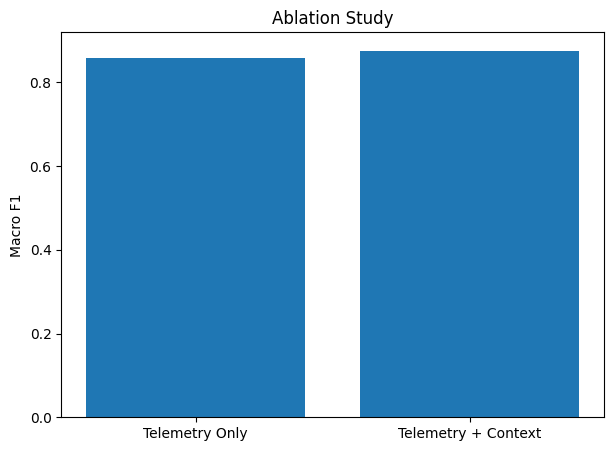

In [19]:
plt.figure(figsize=(7, 5))

plt.bar(ablation["Model"], ablation["Macro_F1"])

plt.ylabel("Macro F1")
plt.title("Ablation Study")

plt.show()

# Final Leakage-Free Model

Train on the full dataset after validating performance.

In [20]:
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print(X_resampled.shape)
print(y_resampled.shape)

(19304, 45)
(19304,)


In [21]:
final_model = LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42
)

final_model.fit(X_resampled, y_resampled)

[LightGBM] [Info] Number of positive: 9652, number of negative: 9652
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002058 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10891
[LightGBM] [Info] Number of data points in the train set: 19304, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,max_depth,6
,learning_rate,0.05
,n_estimators,300
,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [22]:
joblib.dump(final_model, "../models/lightgbm_predictive_maintenance_final.pkl")

print("Model saved successfully.")

Model saved successfully.


# Feature Importance Analysis

In [23]:
importance = pd.DataFrame(
    {"feature": X.columns, "importance": final_model.feature_importances_}
)

importance = importance.sort_values(by="importance", ascending=False)

importance.head(20)

,feature,importance
4,Torque__Nm_,857
31,temp_difference,641
3,Rotational_speed__rpm_,618
33,Process_temperature__K__change,587
32,Air_temperature__K__change,466
36,Tool_wear__min__change,384
13,Rotational_speed__rpm__roll_std,372
5,Tool_wear__min_,301
43,wear_x_demand,276
10,Tool_wear__min__roll_mean,226


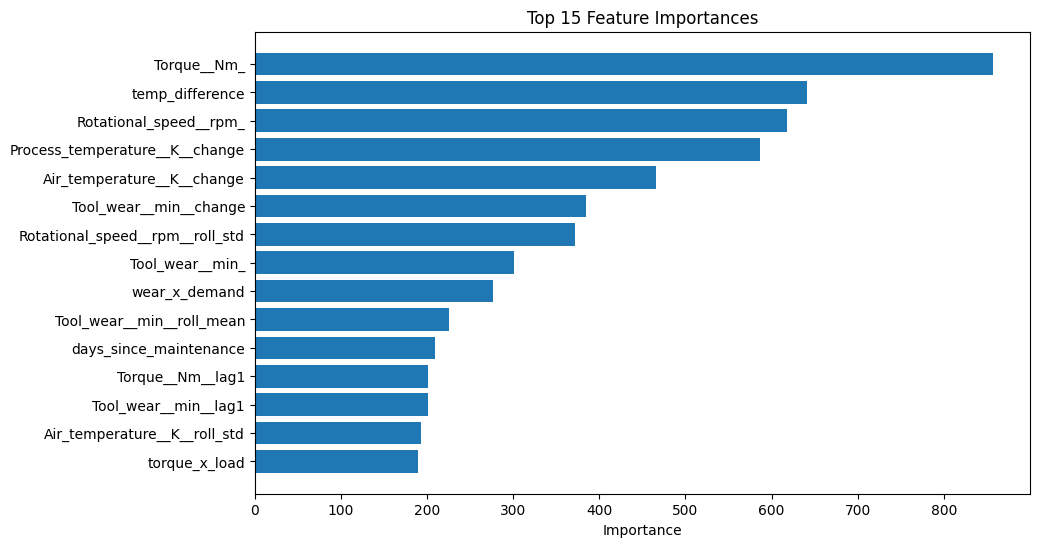

In [24]:
top_features = importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(top_features["feature"], top_features["importance"])

plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importances")

plt.xlabel("Importance")

plt.show()